In [17]:
from osa_simple import YeniOSA
import matplotlib.pyplot as plt

In [18]:
IP = "192.168.54.1"
PORT = 5025

RESOURCE = f"TCPIP0::{IP}::{PORT}::SOCKET"

RESOURCE

'TCPIP0::192.168.54.1::5025::SOCKET'

In [19]:
osa = YeniOSA(RESOURCE)

osa

In [20]:
osa.connect()

print("Conectado")
print(osa.idn)

Conectado
EXFO,OSA20 FC/APC,YO161110143,2.0.6.0


Congigurar el barrido

In [21]:
CENTER = 1570
SPAN = 80
RESOLUTION = 0.05
SENSITIVITY = -70

osa.setup_sweep(
    center_nm=CENTER,
    span_nm=SPAN,
    resolution_nm=RESOLUTION,
    sensitivity_dbm=SENSITIVITY,
)

In [23]:
osa.run_sweep(
    trace=1,
    averages=1,
    post_sweep_delay_s=10,
)

Sweep started, waiting for completion...
Sweep progress: 100%
Waiting 10 s before reading trace data...


In [24]:
trace = osa.get_trace(trace=1)

Reading trace metadata...
Trace points reported by OSA: 40001
Reading trace power data...


In [25]:
dir(trace)

['__annotate_func__',
 '__annotations_cache__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'power_dbm',
 'save_txt',
 'wavelength_nm']

In [26]:
trace.wavelength_nm[:100]

array([1530.   , 1530.002, 1530.004, 1530.006, 1530.008, 1530.01 ,
       1530.012, 1530.014, 1530.016, 1530.018, 1530.02 , 1530.022,
       1530.024, 1530.026, 1530.028, 1530.03 , 1530.032, 1530.034,
       1530.036, 1530.038, 1530.04 , 1530.042, 1530.044, 1530.046,
       1530.048, 1530.05 , 1530.052, 1530.054, 1530.056, 1530.058,
       1530.06 , 1530.062, 1530.064, 1530.066, 1530.068, 1530.07 ,
       1530.072, 1530.074, 1530.076, 1530.078, 1530.08 , 1530.082,
       1530.084, 1530.086, 1530.088, 1530.09 , 1530.092, 1530.094,
       1530.096, 1530.098, 1530.1  , 1530.102, 1530.104, 1530.106,
       1530.108, 1530.11 , 1530.112, 1530.114, 1530.116, 1530.118,
       1530.12 , 1530.122, 1530.124, 1530.126, 1530.128, 1530.13 ,
       1530.132, 1530.134, 1530.136, 1530.138, 1530.14 , 1530.142,
       1530.144, 1530.146, 1530.148, 1530.15 , 1530.152, 1530.154,
       1530.156, 1530.158, 1530.16 , 1530.162, 1530.164, 1530.166,
       1530.168, 1530.17 , 1530.172, 1530.174, 1530.176, 1530.

In [27]:
trace.power_dbm[:100]

array([-100.       , -100.       , -100.       , -100.       ,
       -100.       , -100.       , -100.       , -100.       ,
       -100.       , -100.       , -100.       , -100.       ,
       -100.       , -100.       , -100.       , -100.       ,
       -100.       , -100.       , -100.       , -100.       ,
       -100.       , -100.       ,  -82.945152 ,  -85.8260328,
       -100.       , -100.       , -100.       , -100.       ,
       -100.       , -100.       , -100.       ,  -82.232704 ,
        -75.1095224,  -77.4394226, -100.       , -100.       ,
       -100.       , -100.       , -100.       , -100.       ,
        -77.322798 ,  -75.2907376,  -73.7949308,  -71.2917583,
        -71.9936116,  -73.9810564,  -73.0046019,  -73.4418662,
        -73.5677851,  -72.6788319,  -74.7901304,  -74.2403086,
        -70.372515 ,  -69.3796352,  -68.1269276,  -66.9721745,
        -66.6958286,  -66.6956068,  -66.6557984,  -65.9907164,
        -65.5182207,  -65.620021 ,  -65.6014454,  -65.8

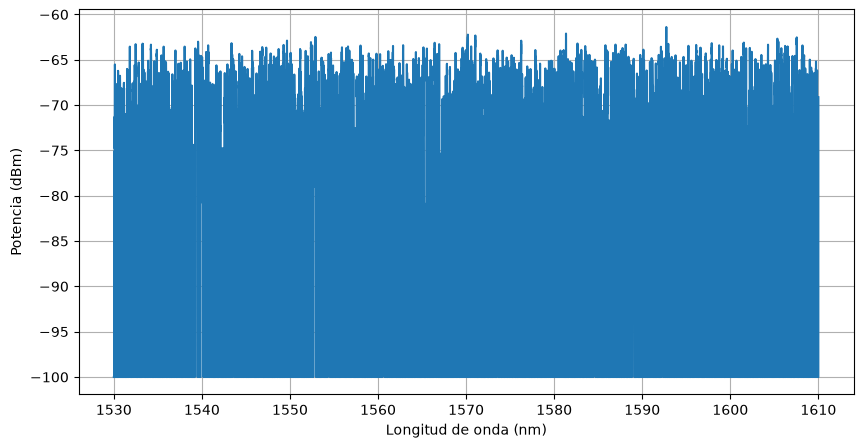

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    trace.wavelength_nm,
    trace.power_dbm
)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Potencia (dBm)")
plt.grid(True)

In [29]:
osa.close()